In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


In [2]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data[["MedInc","HouseAge","AveRooms","Population","Latitude","Longitude"]], data.target.rename("MedianHouseValue")], axis=1)

df.head()

,MedInc,HouseAge,AveRooms,Population,Latitude,Longitude,MedianHouseValue
0,8.3252,41.0,6.984127,322.0,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,2401.0,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,496.0,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,558.0,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,565.0,37.85,-122.25,3.422


In [3]:
X = df.drop("MedianHouseValue", axis=1)
y = df["MedianHouseValue"]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split( X_scaled, y, test_size=0.2,
                                                     random_state=42)

In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression" : Ridge(alpha=1.0),
    "Decision Tree" : DecisionTreeRegressor(max_depth=5)
}

In [10]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    rmse = mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results[name] = {
    "RMSE" : rmse,
    "R2 Score" : r2
    }

results_df = pd.DataFrame(results).T
results_df

,RMSE,R2 Score
Linear Regression,0.548520,0.581413
Ridge Regression,0.548519,0.581414
Decision Tree,0.587792,0.551444


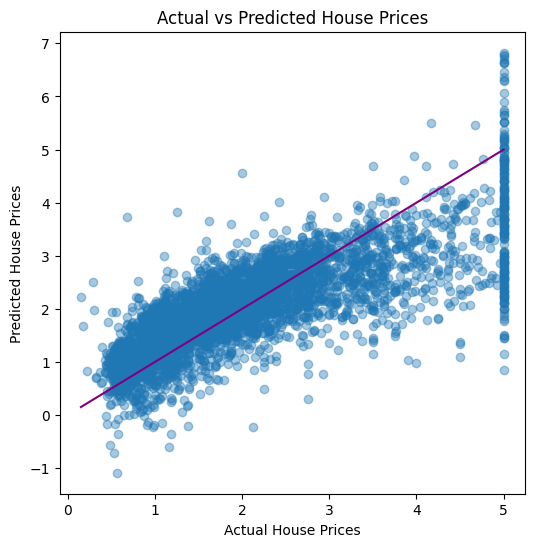

In [14]:
best_model = LinearRegression()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="Purple")
plt.show()